In [1]:
import pandas as pd

airbnb_data = "C:\\Users\\rache\\Downloads\\cse2600\\airbnb_data\\Airbnb_data_cleaned2.csv" #path for csv

df = pd.read_csv(airbnb_data) #read in the data

print('Rows:', len(df)) #num of rows
print('Columns:', len(df.columns)) #num of columns

Rows: 80762
Columns: 18


In [2]:
df_area1 = df[(df["area"] == 1) & (df["price_outlier"] == 0)] #na
df_area2 = df[(df["area"] == 2) & (df["price_outlier"] == 0)] #europe
df_area3 = df[(df["area"] == 3) & (df["price_outlier"] == 0)] #asia

print('Rows area 1:', len(df_area1)) #num of rows
print('Rows area 2:', len(df_area2)) #num of rows
print('Rows area 3:', len(df_area3)) #num of rows

Rows area 1: 31519
Rows area 2: 20083
Rows area 3: 23629


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)


#area 1 (North America)
train1, test1 = train_test_split(df_area1, train_size=25215, random_state=42)
#chose 25215 cuz thats 80%

# Split data into features (X) and target (y) for training and testing
y_train1 = train1['price']
X_train1 = train1.drop(['price'], axis=1)
y_test1 = test1['price']
X_test1 = test1.drop(['price'], axis=1)


#area 2 (Europe)
train2, test2 = train_test_split(df_area2, train_size=16066, random_state=42)
#chose 16066 cuz thats 80%

# Split data into features (X) and target (y) for training and testing
y_train2 = train2['price']
X_train2 = train2.drop(['price'], axis=1)
y_test2 = test2['price']
X_test2 = test2.drop(['price'], axis=1)


#area 3 (Asia)
train3, test3 = train_test_split(df_area3, train_size=18903, random_state=42)
#chose 18903 cuz thats 80%

# Split data into features (X) and target (y) for training and testing
y_train3 = train3['price']
X_train3 = train3.drop(['price'], axis=1)
y_test3 = test3['price']
X_test3 = test3.drop(['price'], axis=1)

In [12]:
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.model_selection import cross_validate
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

leaf_sizes = list(range(2,21))
cv_scores1 = []
cv_scores2 = []
cv_scores3 = []

#area 1
for size in leaf_sizes:
    model1 = DTR(max_leaf_nodes=size, random_state=2)
    # use neg_mean_squared_error or r2 for scoring
    scores1 = cross_validate(model1, X_train1, y_train1, cv=5, scoring='neg_mean_squared_error')
    mean_score1 = np.mean(scores1['test_score'])   # negative MSE
    cv_scores1.append(mean_score1)

best_size1 = leaf_sizes[np.argmax(cv_scores1)]
print("\nBest number of leaf nodes (area 1):", best_size1)

final_model = DTR(max_leaf_nodes=best_size1, random_state=42)
final_model.fit(X_train1, y_train1)

y_pred1 = final_model.predict(X_test1)
test_mse = mean_squared_error(y_test1, y_pred1)
print(f"Test MSE (best model area 1): {test_mse:.4f}")

#area 2
for size in leaf_sizes:
    model2 = DTR(max_leaf_nodes=size, random_state=2)
    # use neg_mean_squared_error or r2 for scoring
    scores2 = cross_validate(model2, X_train2, y_train2, cv=5, scoring='neg_mean_squared_error')
    mean_score2 = np.mean(scores2['test_score'])   # negative MSE
    cv_scores2.append(mean_score2)

best_size2 = leaf_sizes[np.argmax(cv_scores2)]
print("\nBest number of leaf nodes (area 2):", best_size2)

final_model = DTR(max_leaf_nodes=best_size2, random_state=42)
final_model.fit(X_train2, y_train2)

y_pred2 = final_model.predict(X_test2)
test_mse = mean_squared_error(y_test2, y_pred2)
print(f"Test MSE (best model area 2): {test_mse:.4f}")

#area 3
for size in leaf_sizes:
    model3 = DTR(max_leaf_nodes=size, random_state=2)
    # use neg_mean_squared_error or r2 for scoring
    scores3 = cross_validate(model3, X_train3, y_train3, cv=5, scoring='neg_mean_squared_error')
    mean_score3 = np.mean(scores3['test_score'])   # negative MSE
    cv_scores3.append(mean_score3)

best_size3 = leaf_sizes[np.argmax(cv_scores3)]
print("\nBest number of leaf nodes (area 3):", best_size3)

final_model = DTR(max_leaf_nodes=best_size3, random_state=42)
final_model.fit(X_train3, y_train3)

y_pred3 = final_model.predict(X_test3)
test_mse = mean_squared_error(y_test3, y_pred3)
print(f"Test MSE (best model area 3): {test_mse:.4f}")


Best number of leaf nodes (area 1): 20
Test MSE (best model area 1): 5938.2180

Best number of leaf nodes (area 2): 20
Test MSE (best model area 2): 4828.8439

Best number of leaf nodes (area 3): 20
Test MSE (best model area 3): 4726.0408


In [13]:
r2_area1 = r2_score(y_test1, y_pred1)
print("Random Forest (area 1) R²:", r2_area1)

r2_area2 = r2_score(y_test2, y_pred2)
print("Random Forest (area 2) R²:", r2_area2)

r2_area3 = r2_score(y_test3, y_pred3)
print("Random Forest (area 3) R²:", r2_area3)

Random Forest (area 1) R²: 0.4682406673321321
Random Forest (area 2) R²: 0.4820598967168338
Random Forest (area 3) R²: 0.4823128861673752


In [5]:
tree1 = DTR(max_leaf_nodes=20)
tree1.fit(X_train1, y_train1)

tree2 = DTR(max_leaf_nodes=20)
tree2.fit(X_train2, y_train2)

tree3 = DTR(max_leaf_nodes=20)
tree3.fit(X_train3, y_train3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,20
,min_impurity_decrease,0.0
,ccp_alpha,0.0


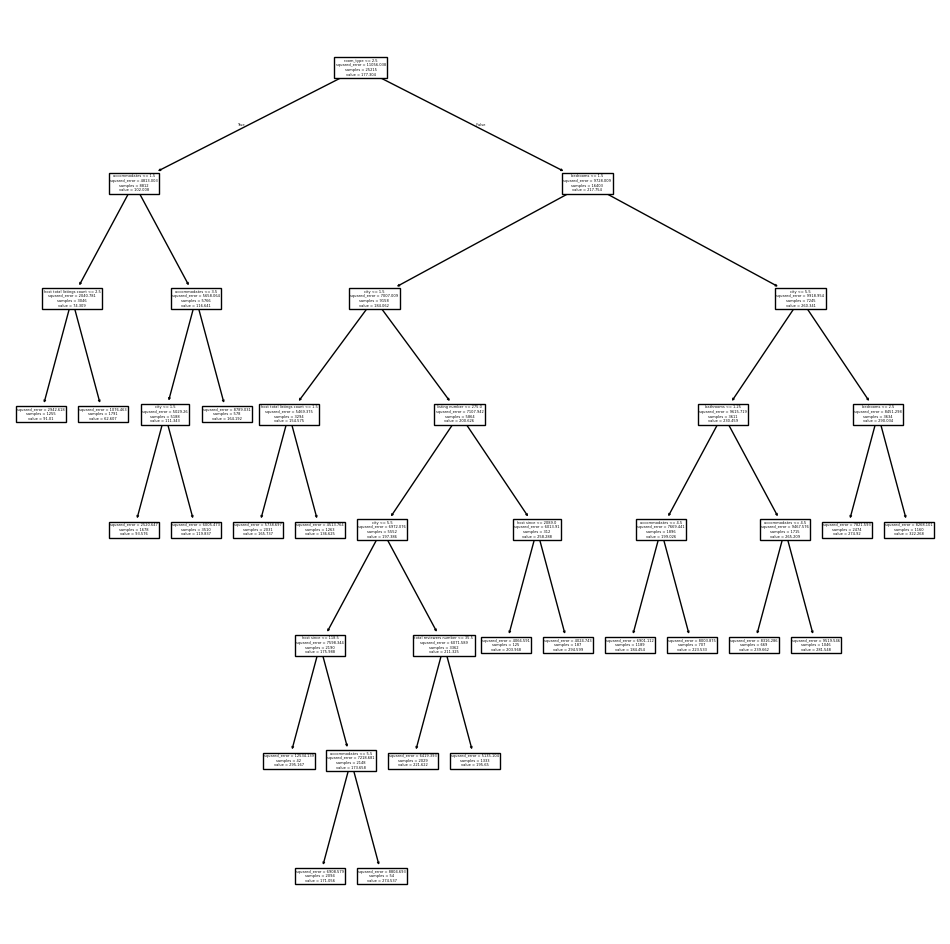

In [6]:
from matplotlib.pyplot import subplots
feature_names1 = list(X_train1.columns)
ax = subplots(figsize=(12,12))[1]
plot_tree(tree1,
          feature_names=feature_names1,
          ax=ax);

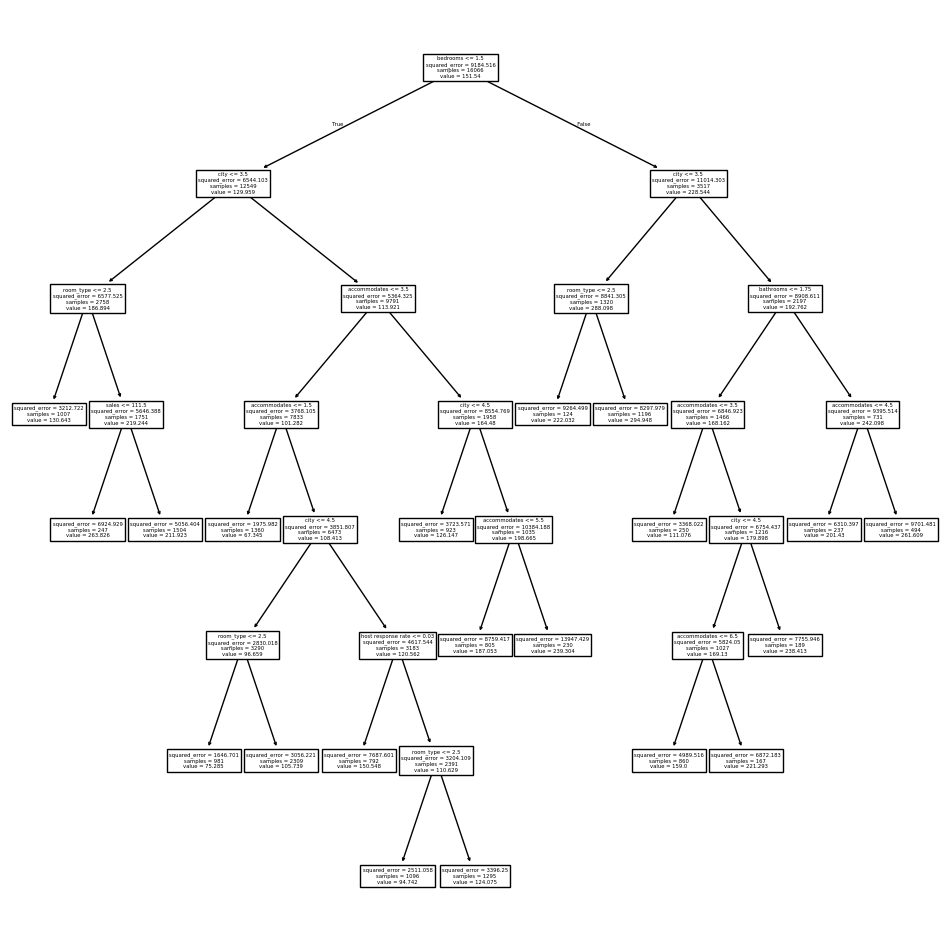

In [7]:
from matplotlib.pyplot import subplots
feature_names2 = list(X_train2.columns)
ax = subplots(figsize=(12,12))[1]
plot_tree(tree2,
          feature_names=feature_names2,
          ax=ax);

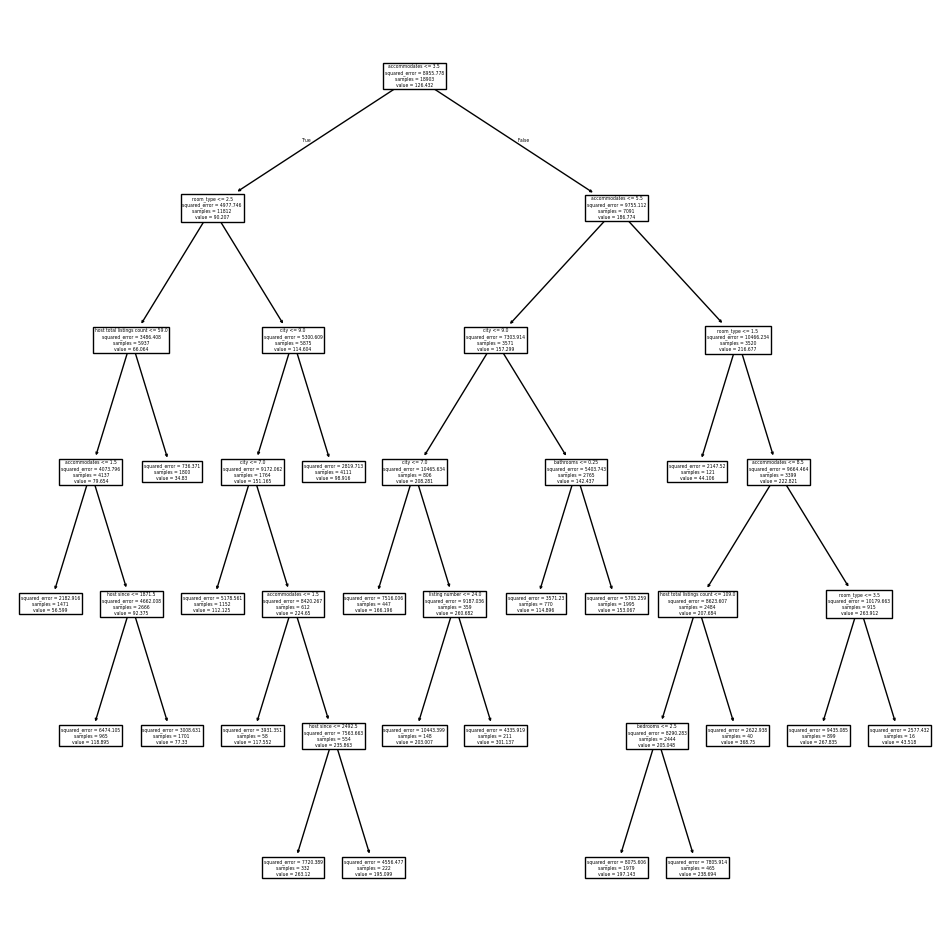

In [8]:
from matplotlib.pyplot import subplots
feature_names3 = list(X_train3.columns)
ax = subplots(figsize=(12,12))[1]
plot_tree(tree3,
          feature_names=feature_names3,
          ax=ax);

In [9]:
# Feature importance list (1)
feature_imp = pd.DataFrame(
    {'importance1':tree1.feature_importances_},
    index=feature_names1)
feature_imp.sort_values(by='importance1', ascending=False)

,importance1
room_type,0.588550
bedrooms,0.193936
city,0.102236
accommodates,0.053498
bathrooms,0.030227
host total listings count,0.009620
host since,0.009377
listing number,0.008397
total reviewers number,0.004159
guest favourite,0.000000


In [10]:
# Feature importance list (2)
feature_imp = pd.DataFrame(
    {'importance2':tree2.feature_importances_},
    index=feature_names2)
feature_imp.sort_values(by='importance2', ascending=False)

,importance2
bedrooms,0.372864
city,0.324135
accommodates,0.150059
room_type,0.094482
bathrooms,0.037239
host response rate,0.013240
sales,0.007982
host Certification,0.000000
guest favourite,0.000000
host total listings count,0.000000


In [11]:
# Feature importance list (3)
feature_imp = pd.DataFrame(
    {'importance3':tree3.feature_importances_},
    index=feature_names3)
feature_imp.sort_values(by='importance3', ascending=False)

,importance3
accommodates,0.617783
city,0.154509
room_type,0.137358
host total listings count,0.042771
host since,0.020093
listing number,0.010022
bathrooms,0.009686
bedrooms,0.007778
guest favourite,0.000000
total reviewers number,0.000000
